# Training model Logistic Regression trên Dữ liệu sạch và Dữ liệu độc

Notebook này mô phỏng lại tấn công label flipping (đảo nhãn) lên tập dữ liệu huấn luyện, sau đó huấn luyện hai mô hình Logistic Regression độc lập — một trên dữ liệu sạch `(train_dfs["0"])` và một trên dữ liệu đã bị đầu độc `(train_dfs["45"])` — nhằm quan sát mức độ suy giảm hiệu năng (accuracy) và sự thay đổi trong quá trình hội tụ (loss) khi mô hình bị huấn luyện trên dữ liệu bị tấn công.

Cả hai mô hình dùng chung tập kiểm tra (X_test, y_test) — vốn không bị đầu độc — để đảm bảo việc so sánh điểm số là công bằng: sự khác biệt về accuracy chỉ đến từ chất lượng dữ liệu huấn luyện, không phải từ sự khác biệt của tập test.

In [1]:
import sys, os 
from pathlib import Path

project_root = Path.cwd().parent 

os.chdir(project_root)
sys.path.append(str(project_root))

In [24]:
# Python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Project
from src.utils.math import *
from src.preprocess import X_test, y_test, train_dfs

## 1. Training model trên Dữ liệu sạch

Phần này huấn luyện mô hình baseline — mô hình "chưa bị tấn công" — làm mốc so sánh cho phần 2.

### 1.1. Chuẩn bị

Lấy tập dữ liệu huấn luyện sạch từ `train_dfs["0"]` (key "0" tương ứng tỉ lệ đầu độc 0%, tức dữ liệu gốc chưa bị đảo nhãn). Tách thành X_train_cleaned (đặc trưng) và y_train_cleaned (nhãn, cột "attack").

Dữ liệu đặc trưng có các cột với thang đo (scale) rất khác nhau — có cột nằm trong khoảng 0 – 1, có cột lên tới hàng nghìn — nên cần chuẩn hóa bằng `StandardScaler` trước khi đưa vào `gradient descent`, nếu không trọng số sẽ hội tụ rất chậm hoặc phân kỳ (weight explosion). `X_test` cũng được scale bằng cùng một `scaler_cleaned` đã fit trên tập train sạch, để tránh rò rỉ dữ liệu (data leakage) và đảm bảo tính nhất quán khi so sánh với phần dữ liệu poisoned (vì X của tập poisoned dùng chung đặc trưng gốc).

Hai hằng số điều khiển quá trình huấn luyện:

- `C_val = 0.01`: learning rate của gradient descent.
- `epochs = 1000`: số vòng lặp huấn luyện.

In [3]:
data_training_cleaned = train_dfs["0"]

# print(f"data_training_cleaned:\n{data_training_cleaned}\n")

X_train_cleaned, y_train_cleaned = data_training_cleaned["X"], data_training_cleaned["attack"]

# Scalling data
scaler_cleaned = StandardScaler()
X_train_cleaned = scaler_cleaned.fit_transform(X_train_cleaned)

X_test = scaler_cleaned.transform(X_test) # Because X on poisoned data is the same, so we only need to scale once

# print(f"X_train_cleaned:\n{X_train_cleaned}\n")
# print(f"X_test:\n{X_test}\n")
# print(f"y_train_cleaned:\n{y_train_cleaned}\n")

# Const
C_val = 0.01    # To adjust learning rate of model
epochs = 1000   # The number of learning times which the model will learn on one data

### 1.2. Hai trọng số

Khởi tạo trọng số mô hình ở giá trị 0:

- `w_cleaned`: vector trọng số, kích thước bằng số đặc trưng đầu vào.
- `b_cleaned`: bias (hệ số chặn), khởi tạo bằng 0.

In [4]:
w_cleaned = np.zeros(X_train_cleaned.shape[1])
b_cleaned = 0

### 1.3. Training model

Huấn luyện bằng batch gradient descent thủ công (tự cài đặt, không dùng sklearn):

Tính `z = X @ w + b`.
Đưa qua hàm `sigmoid(z)` để ra xác suất dự đoán `y_prob`.
Tính gradient `(dw, db)` từ chênh lệch giữa `y_prob` và nhãn thật.
Cập nhật `w`, `b` theo hướng ngược gradient, với bước nhảy `C_val`.

Lặp lại `epochs + 1` lần. Vì dữ liệu đã được chuẩn hóa ở bước 1.1, quá trình này hội tụ ổn định, không phát sinh cảnh báo tràn số (overflow) như khi chưa scale.

In [5]:
for epoch in range(epochs + 1):
    z = X_train_cleaned @ w_cleaned + b_cleaned

    y_prob = sigmoid(z)

    dw, db = gradient(X_train_cleaned, y_train_cleaned, y_prob)

    w_cleaned -= C_val * dw
    b_cleaned -= C_val * db

### 1.4. Dự đoán dữ liệu

Dùng `w_cleaned`, `b_cleaned` đã huấn luyện để dự đoán trên `X_test`: tính xác suất, ngưỡng `>= 0.5` để ra nhãn dự đoán, rồi so với `y_test` bằng `accuracy_score`.

Kết quả: `accuracy ≈ 96.44%` — mô hình huấn luyện trên dữ liệu sạch đạt độ chính xác cao, cho thấy dữ liệu gốc có khả năng phân tách tốt giữa hai lớp.

In [22]:
z_test_cleaned = X_test @ w_cleaned + b_cleaned
y_prob_cleaned = sigmoid(z_test_cleaned)

# Predict
y_pred_cleaned = (y_prob_cleaned >= 0.5).astype(int)

acc_cleaned = accuracy_score(y_test, y_pred_cleaned)

print(f"Accuracy score: {acc_cleaned}")

Accuracy score: 0.9644


/home/khoi/workspace/label-flipping-project/src/utils/math.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


## 2. Training model trên Dữ liệu độc

Phần này lặp lại đúng quy trình ở phần 1, nhưng trên tập dữ liệu đã bị tấn công label flipping — mô phỏng kịch bản kẻ tấn công cố tình đảo ngược nhãn của một phần mẫu huấn luyện để đánh lừa mô hình.

### 2.1. Chuẩn bị

Lấy dữ liệu từ `train_dfs["45"]` — key `"45"` tương ứng 45% dữ liệu huấn luyện đã bị đảo nhãn (label flipping poisoning). Tách thành `X_train_poisoned`, `y_train_poisoned`, rồi scale bằng một `StandardScaler` riêng (`scaler_poisoned`) — do fit lại trên chính phân bố của tập poisoned, phản ánh đúng kịch bản thực tế: kẻ tấn công (hoặc hệ thống phòng thủ) chỉ có quyền truy cập vào dữ liệu huấn luyện đã bị nhiễm, không biết trước phân bố dữ liệu sạch.

In [7]:
data_training_poisoned = train_dfs["45"]

# print(f"data_training_poisoned:\n{data_training_poisoned}\n")

X_train_poisoned, y_train_poisoned = data_training_poisoned["X"], data_training_poisoned["attack"]

# Scalling data
scaler_poisoned = StandardScaler()
X_train_poisoned = scaler_poisoned.fit_transform(X_train_poisoned)

# print(f"X_train_poisoned:\n{X_train_poisoned}\n")
# print(f"y_train_poisoned:\n{y_train_poisoned}\n")

### 2.2. Hai trọng số

Khởi tạo lại `w_poisoned`, `b_poisoned` bằng 0 — độc lập hoàn toàn với mô hình ở phần 1, đảm bảo hai mô hình không ảnh hưởng lẫn nhau.

In [8]:
w_poisoned = np.zeros(X_train_poisoned.shape[1])
b_poisoned = 0

### 2.3. Training model

Chạy đúng vòng lặp gradient descent như mục 1.3, với cùng `C_val` và `epochs`, nhưng trên `X_train_poisoned` / `y_train_poisoned`. Vì nhãn đã bị đảo ở 45% mẫu, tín hiệu gradient mà mô hình học được sẽ mâu thuẫn với ranh giới quyết định thật — mô hình bị "dạy sai" một cách có chủ đích.

In [9]:
for epoch in range(epochs + 1):
    z = X_train_poisoned @ w_poisoned + b_poisoned

    y_prob = sigmoid(z)

    dw, db = gradient(X_train_poisoned, y_train_poisoned, y_prob)

    w_poisoned -= C_val * dw
    b_poisoned -= C_val * db

### 2.4. Dự đoán dữ liệu

Dự đoán trên cùng tập `X_test`, `y_test` như phần 1 (không bị đầu độc), để đo mức độ suy giảm khả năng tổng quát hoá do bị tấn công.

Kết quả: `accuracy ≈ 60.2%` — giảm mạnh so với `96.44%` của mô hình sạch, gần chạm mức của một bộ phân loại ngẫu nhiên (50% với bài toán nhị phân cân bằng). Đây là bằng chứng định lượng cho thấy tấn công label flipping ở tỉ lệ 45% đã phá hủy gần như hoàn toàn khả năng học ranh giới quyết định đúng của mô hình.

| Kịch bản |	Tỉ lệ nhãn bị đảo |	Accuracy trên test |
|---|---:|---|
| Clean |	0%	| 96.44% |
| Poisoned |	45%	| 60.20% |
| Chênh lệch |	—	| -36.24 điểm % |

In [23]:
z_test_poisoned = X_test @ w_poisoned + b_poisoned
y_prob_poisoned = sigmoid(z_test_poisoned)

# Predict
y_pred_poisoned = (y_prob_poisoned >= 0.5).astype(int)

acc_poisoned = accuracy_score(y_test, y_pred_poisoned)

print(f"Accuracy score: {acc_poisoned}")

Accuracy score: 0.602


/home/khoi/workspace/label-flipping-project/src/utils/math.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


## 3. Đánh giá hiệu suất model

Sử dụng lại các kết quả đã có ở phần 1 và phần 2 (`y_pred_cleaned`, `y_pred_poisoned`, `acc_cleaned`, `acc_poisoned`) để so sánh trực quan hiệu suất giữa hai mô hình trên nhiều thước đo khác nhau, thay vì chỉ dừng lại ở một con số accuracy.

### 3.1. Accuracy score

Vẽ biểu đồ cột so sánh `acc_cleaned` và `acc_poisoned` để thấy rõ mức chênh lệch accuracy giữa mô hình huấn luyện trên dữ liệu sạch và mô hình huấn luyện trên dữ liệu bị đầu độc.

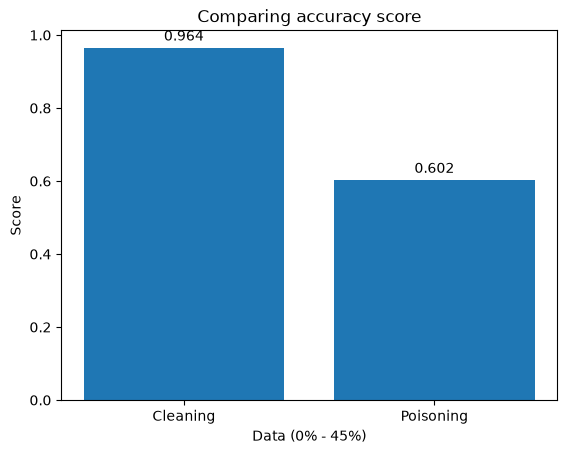

In [28]:
bars = plt.bar(["Cleaning", "Poisoning"], [acc_cleaned, acc_poisoned])
plt.bar_label(bars, fmt="%.3f", padding=3)

plt.title("Comparing accuracy score")
plt.xlabel("Data (0% - 45%)")
plt.ylabel("Score")
plt.show()

### 3.2. Precision, Recall, F1-score

Accuracy có thể không phản ánh đầy đủ chất lượng mô hình, đặc biệt khi hai lớp trong `attack` không cân bằng. Phần này tính thêm `precision`, `recall`, `f1-score` cho cả hai mô hình, rồi vẽ biểu đồ cột nhóm (grouped bar chart) để so sánh cả ba chỉ số trên cùng một hình.

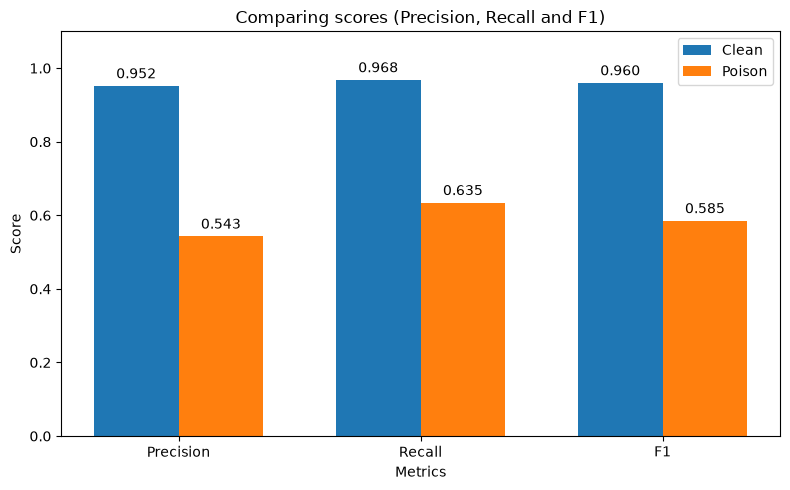

In [12]:
# Precision
prec_cleaned = precision_score(y_test, y_pred_cleaned)
prec_poisoned = precision_score(y_test, y_pred_poisoned)

# Recall
recall_cleaned = recall_score(y_test, y_pred_cleaned)
recall_poisoned = recall_score(y_test, y_pred_poisoned)

# F1
f1_cleaned = f1_score(y_test, y_pred_cleaned)
f1_poisoned = f1_score(y_test, y_pred_poisoned)

categories = ["Precision", "Recall", "F1"]

scores = {
    "Precision": [prec_cleaned, prec_poisoned],
    "Recall": [recall_cleaned, recall_poisoned],
    "F1": [f1_cleaned, f1_poisoned]
}

cleaned_scores = [prec_cleaned, recall_cleaned, f1_cleaned]
poisoned_scores = [prec_poisoned, recall_poisoned, f1_poisoned]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# Clean
bars_clean = ax.bar(
    x - width/2,
    cleaned_scores,
    width,
    label="Clean"
)

# Poison
bars_poison = ax.bar(
    x + width/2,
    poisoned_scores,
    width,
    label="Poison"
)

# Represent figture on top each comlumns
ax.bar_label(bars_clean, fmt="%.3f", padding=3)
ax.bar_label(bars_poison, fmt="%.3f", padding=3)

# Labels
ax.set_title("Comparing scores (Precision, Recall and F1)")
ax.set_xlabel("Metrics")
ax.set_ylabel("Score")

ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.legend()

# Limit Y
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()


### 3.3. Confusion Matrix

Vẽ confusion matrix cho từng mô hình để xem chi tiết số lượng dự đoán đúng/sai trên từng lớp của `attack`, thay vì chỉ nhìn accuracy tổng — qua đó biết được mô hình nhầm lẫn nhiều hơn ở lớp nào (false positive hay false negative) khi bị huấn luyện trên dữ liệu poisoned.

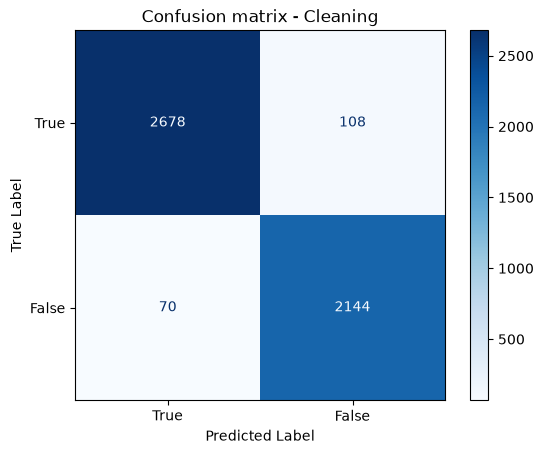

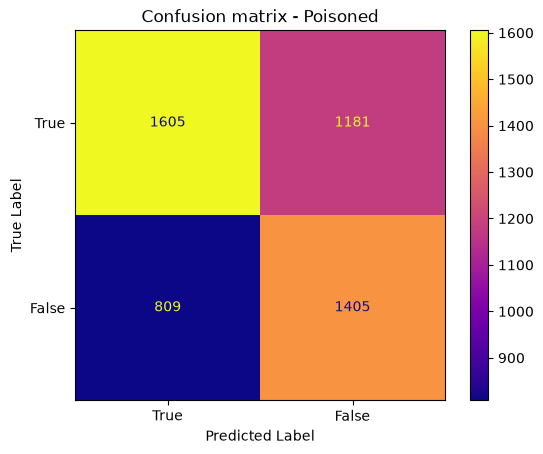

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

# Cleaning
cm_cleaned = confusion_matrix(y_test, y_pred_cleaned)
disp_cleaned = ConfusionMatrixDisplay(
    confusion_matrix=cm_cleaned,
    display_labels=["True", "False"]
)
disp_cleaned.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix - Cleaning")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Poisoning
cm_poisoned = confusion_matrix(y_test, y_pred_poisoned)
disp_poisoned = ConfusionMatrixDisplay(
    confusion_matrix=cm_poisoned,
    display_labels=["True", "False"]
)
disp_poisoned.plot(cmap=plt.cm.plasma)
plt.title("Confusion matrix - Poisoned")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 4. Loss Curve

Phần này huấn luyện lại từ đầu (trọng số mới, không tái sử dụng `w_cleaned`/`w_poisoned` đã huấn luyện ở trên) cho cả hai kịch bản, nhưng lần này ghi lại giá trị loss ở mỗi epoch — trên cả tập train và tập test — để vẽ đường cong hội tụ (loss curve), thay vì chỉ lấy accuracy ở epoch cuối.

### 4.1. Chuẩn bị

Huấn luyện lại từ đầu với bộ trọng số mới (độc lập với `w_cleaned`/`w_poisoned` đã dùng ở phần 1–3), lần này ghi lại giá trị loss ở mỗi epoch cho cả hai kịch bản, làm dữ liệu đầu vào để vẽ loss curve ở mục 4.2.

#### 4.1.1. Training với Dữ liệu độc

Khởi tạo `new_w_poisoned = 0`, `new_b_poisoned = 0`. Ở mỗi epoch:

- Tính loss trên tập train poisoned (`loss_history_poisoned`) — đo mức độ mô hình khớp với nhãn đã bị đảo.
- Tính loss trên tập test sạch (`test_loss_history_poisoned`) — đo khả năng tổng quát hoá thật sự của mô hình.
- Cập nhật trọng số bằng gradient descent như thường lệ.

So sánh hai đường loss này (train vs test) là điểm mấu chốt: nếu loss trên tập train poisoned giảm đều nhưng loss trên tập test không giảm tương ứng (hoặc dao động/tăng), đó là dấu hiệu mô hình đang "học thuộc" nhãn sai thay vì học đúng ranh giới quyết định.

In [14]:
loss_history_poisoned = []
test_loss_history_poisoned = []

new_w_poisoned = np.zeros(X_test.shape[1])
new_b_poisoned = 0

for epoch in range (epochs + 1):
    # Train main model
    z = X_train_poisoned @ new_w_poisoned + new_b_poisoned
    y_prob = sigmoid(z)
    loss_history_poisoned.append(loss(y_train_poisoned, y_prob))

    # Train test model
    z_test = X_test @ new_w_poisoned + new_b_poisoned
    y_prob_test = sigmoid(z_test)
    test_loss_history_poisoned.append(loss(y_test, y_prob_test))

    dw, db = gradient(X_train_poisoned, y_train_poisoned, y_prob)
    new_w_poisoned -= C_val * dw
    new_b_poisoned -= C_val * db

/home/khoi/workspace/label-flipping-project/src/utils/math.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


#### 4.1.2. Training với Dữ liệu sạch

Thực hiện tương tự với `new_w_cleaned`, `new_b_cleaned` trên dữ liệu sạch, ghi lại `loss_history_cleaned` (train) và `test_loss_history_cleaned` (test).

In [16]:
loss_history_cleaned = []
test_loss_history_cleaned = []

new_w_cleaned = np.zeros(X_test.shape[1])
new_b_cleaned = 0

for epoch in range (epochs + 1):
    # Train main model
    z = X_train_cleaned @ new_w_cleaned + new_b_cleaned
    y_prob = sigmoid(z)
    loss_history_cleaned.append(loss(y_train_cleaned, y_prob))

    # Train test model
    z_test = X_test @ new_w_cleaned + new_b_cleaned
    y_prob_test = sigmoid(z_test)
    test_loss_history_cleaned.append(loss(y_test, y_prob_test))

    dw, db = gradient(X_train_cleaned, y_train_cleaned, y_prob)
    new_w_cleaned -= C_val * dw
    new_b_cleaned -= C_val * db

/home/khoi/workspace/label-flipping-project/src/utils/math.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


### 4.2. Vẽ biểu đồ

Vẽ loss curve (train loss và test loss theo epoch) riêng cho từng kịch bản, nhằm quan sát sự khác biệt trong hành vi hội tụ giữa mô hình huấn luyện trên dữ liệu sạch và mô hình huấn luyện trên dữ liệu bị đầu độc.

#### 4.2.1. Poisoned

Vẽ `loss_history_poisoned` và `test_loss_history_poisoned` theo epoch. Kỳ vọng quan sát được: loss trên tập train poisoned giảm dần (mô hình đang tối ưu theo nhãn đã bị đảo), nhưng loss trên tập test sạch giảm chậm hơn nhiều, giữ ở mức cao, hoặc dao động bất thường — phản ánh khoảng cách (gap) giữa "học tốt trên dữ liệu bẩn" và "tổng quát hoá tốt trên dữ liệu thật".

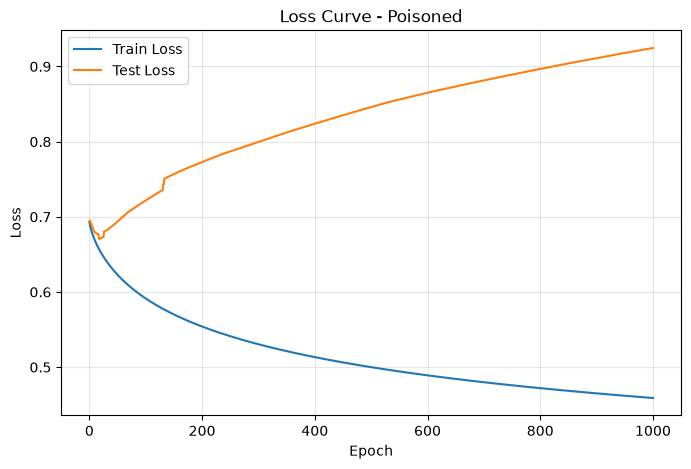

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_poisoned, label="Train Loss")
plt.plot(test_loss_history_poisoned, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve - Poisoned")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 4.2.2. Cleaning

Vẽ tương tự cho dữ liệu sạch. Kỳ vọng: cả hai đường train loss và test loss giảm gần như song song và hội tụ về giá trị thấp, không có khoảng cách lớn giữa train/test — dấu hiệu của một mô hình học đúng và tổng quát hoá tốt.

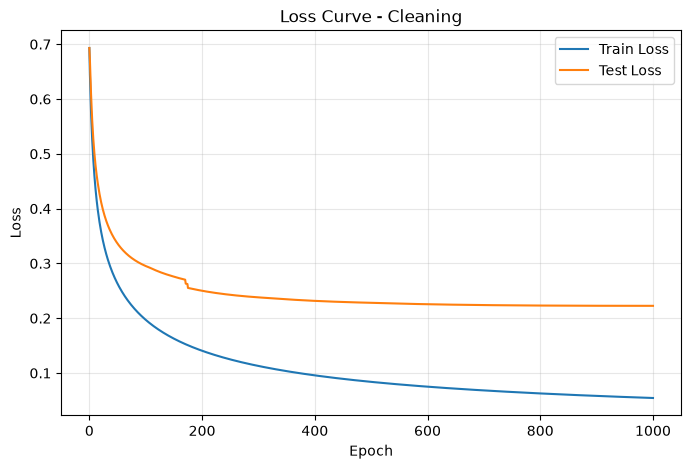

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_cleaned, label="Train Loss")
plt.plot(test_loss_history_cleaned, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve - Cleaning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Kết luận

Thí nghiệm mô phỏng tấn công label flipping ở tỉ lệ 45% cho thấy tác động rõ rệt lên mô hình Logistic Regression:

- Accuracy giảm mạnh: từ `96.44%` (sạch) xuống còn `60.20%` (bị tấn công) — mất khoảng 36 điểm phần trăm, dù mô hình vẫn được huấn luyện đúng quy trình (cùng learning rate, cùng số epoch, cùng tập test).

- Loss curve cho thấy sự khác biệt về hành vi hội tụ: mô hình sạch có train loss và test loss bám sát nhau, trong khi mô hình poisoned có khoảng cách lớn hơn giữa hai đường này — mô hình đang tối ưu theo một mục tiêu (nhãn bị đảo) khác với mục tiêu thật cần đạt (phân loại đúng trên dữ liệu sạch).

- Kết quả này khẳng định logistic regression không có khả năng tự kháng cự trước tấn công đầu độc nhãn ở mức 45% — đây là cơ sở để phần tiếp theo của dự án (`src/defend`) triển khai các cơ chế phòng thủ nhằm khôi phục lại hiệu năng gần với mức baseline `96.44%`.